In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load the car dataset
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

# Display the first 5 rows
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
# Check the dataset structure

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (4340, 8)

Column Names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

Data Types:
name               str
year             int64
selling_price    int64
km_driven        int64
fuel               str
seller_type        str
transmission       str
owner              str
dtype: object

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate Rows: 763


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values again
print("Missing Values After Cleaning:")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning:", df.shape)

Missing Values After Cleaning:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Dataset Shape After Cleaning: (3577, 8)


In [6]:
# Feature Engineering

# Create car age
reference_year = df['year'].max() + 1
df['car_age'] = reference_year - df['year']

# Extract car brand from the car name
df['brand'] = df['name'].str.split().str[0]

# Display the new features
df[['name', 'year', 'car_age', 'brand']].head()

,name,year,car_age,brand
0,Maruti 800 AC,2007,14,Maruti
1,Maruti Wagon R LXI Minor,2007,14,Maruti
2,Hyundai Verna 1.6 SX,2012,9,Hyundai
3,Datsun RediGO T Option,2017,4,Datsun
4,Honda Amaze VX i-DTEC,2014,7,Honda


Selling Price Statistics:
count    3.577000e+03
mean     4.739125e+05
std      5.093018e+05
min      2.000000e+04
25%      2.000000e+05
50%      3.500000e+05
75%      6.000000e+05
max      8.900000e+06
Name: selling_price, dtype: float64


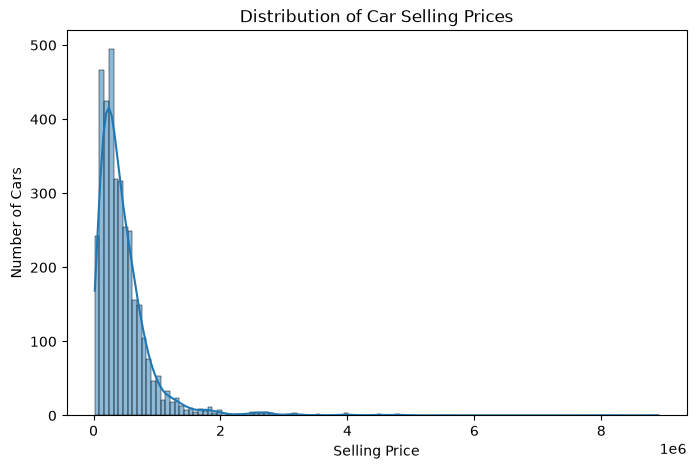

In [7]:
# Explore the selling price

print("Selling Price Statistics:")
print(df['selling_price'].describe())

# Plot the selling price distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['selling_price'], kde=True)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

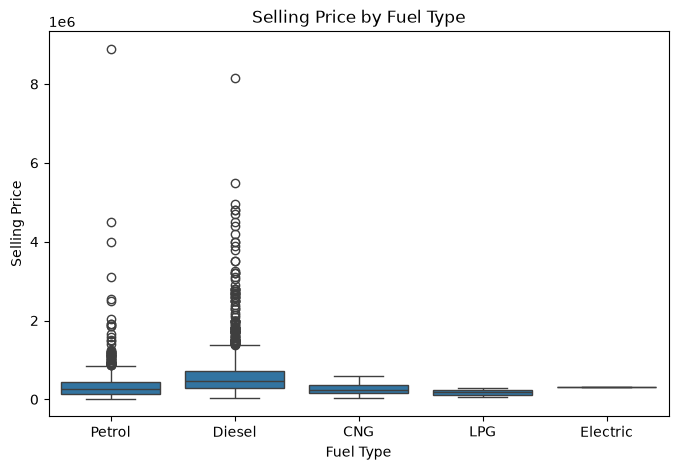

In [8]:
# Price vs Fuel Type

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='fuel',
    y='selling_price'
)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

plt.show()

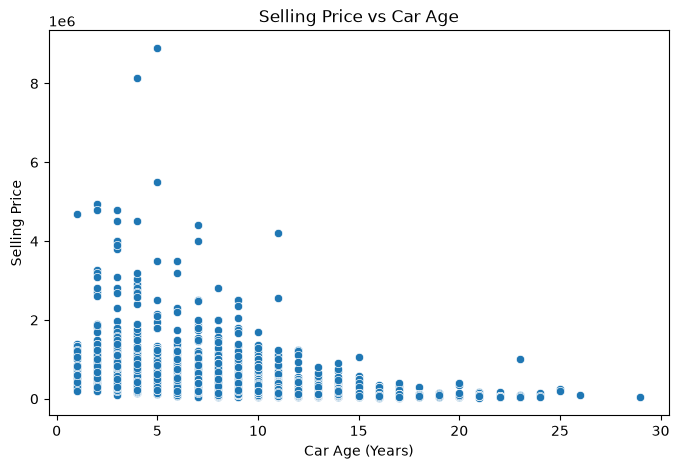

In [9]:
# Price vs Car Age

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='car_age',
    y='selling_price'
)

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')

plt.show()

In [10]:
# Check categorical values

print("Fuel Types:")
print(df['fuel'].value_counts())

print("\nSeller Types:")
print(df['seller_type'].value_counts())

print("\nTransmission Types:")
print(df['transmission'].value_counts())

print("\nOwner Types:")
print(df['owner'].value_counts())

Fuel Types:
fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64

Seller Types:
seller_type
Individual          2832
Dealer               712
Trustmark Dealer      33
Name: count, dtype: int64

Transmission Types:
transmission
Manual       3265
Automatic     312
Name: count, dtype: int64

Owner Types:
owner
First Owner             2218
Second Owner             978
Third Owner              289
Fourth & Above Owner      75
Test Drive Car            17
Name: count, dtype: int64


In [11]:
# Encode categorical variables

df_encoded = pd.get_dummies(
    df,
    columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'],
    drop_first=True
)

print("Encoded Dataset Shape:", df_encoded.shape)
df_encoded.head()

Encoded Dataset Shape: (3577, 44)


,name,year,selling_price,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,Maruti 800 AC,2007,60000,70000,14,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
1,Maruti Wagon R LXI Minor,2007,135000,50000,14,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,Hyundai Verna 1.6 SX,2012,600000,100000,9,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,Datsun RediGO T Option,2017,250000,46000,4,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4,Honda Amaze VX i-DTEC,2014,450000,141000,7,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


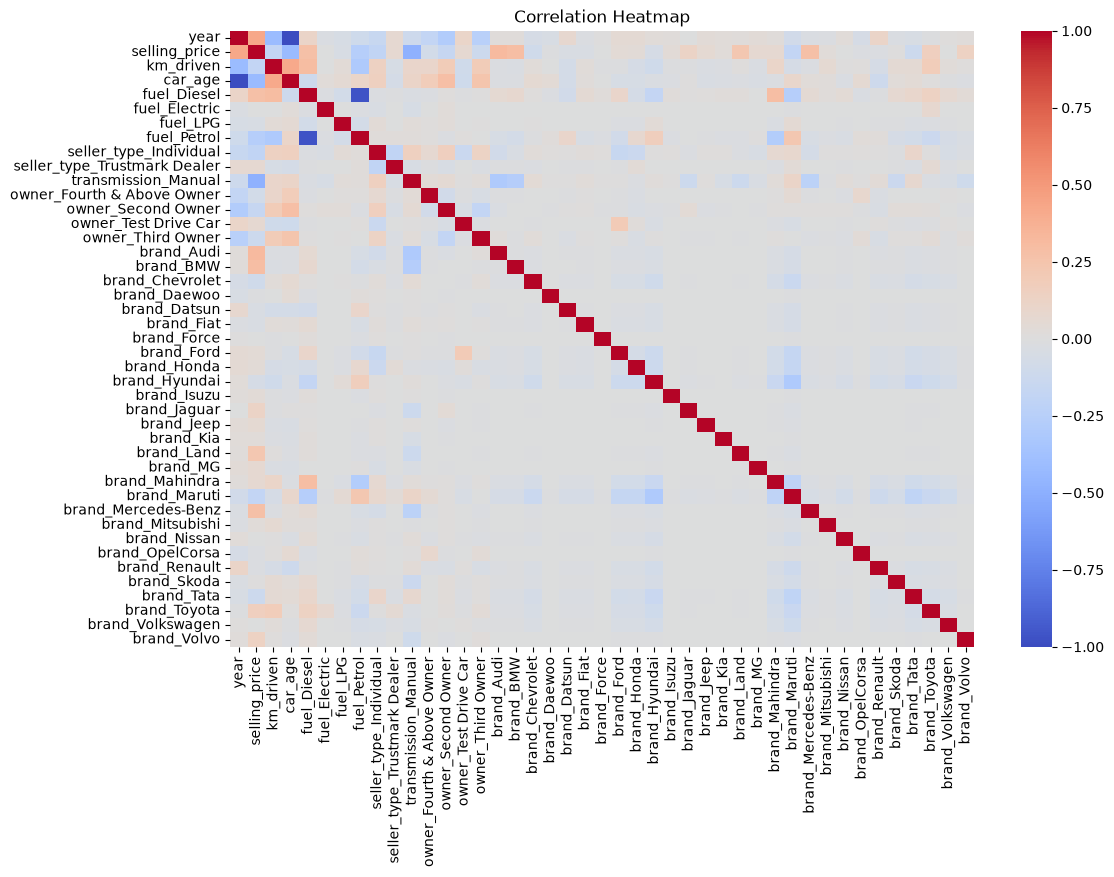

In [12]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation = df_encoded.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=False,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [13]:
# Prepare features and target

X = df_encoded.drop(columns=['selling_price', 'name'])
y = df_encoded['selling_price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2861, 42)
Testing data: (716, 42)


In [14]:
# Train Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [15]:
# Evaluate Linear Regression

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance:")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Performance:
MAE : 185413.76754992883
RMSE: 380273.3498488457
R²  : 0.5510933016219539


In [16]:
from sklearn.ensemble import RandomForestRegressor

In [17]:
# Train Random Forest Regression model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [18]:
# Evaluate Random Forest Regression

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Performance:")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Performance:
MAE : 159293.6736403034
RMSE: 365093.63355667563
R²  : 0.5862168278996627


In [19]:
# Compare model performance

model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regression'],
    'MAE': [mae_linear, mae_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R²': [r2_linear, r2_rf]
})

model_comparison

,Model,MAE,RMSE,R²
0,Linear Regression,185413.76755,380273.349849,0.551093
1,Random Forest Regression,159293.67364,365093.633557,0.586217


In [20]:
# Select the best-performing model based on R²

best_model_name = model_comparison.loc[
    model_comparison['R²'].idxmax(),
    'Model'
]

print("Best Model:", best_model_name)

Best Model: Random Forest Regression


Top Important Features:
                   Feature  Importance
9      transmission_Manual    0.244025
1                km_driven    0.127027
2                  car_age    0.121760
0                     year    0.113241
3              fuel_Diesel    0.070997
14              brand_Audi    0.052723
6              fuel_Petrol    0.042618
28              brand_Land    0.040374
39            brand_Toyota    0.037311
7   seller_type_Individual    0.018456


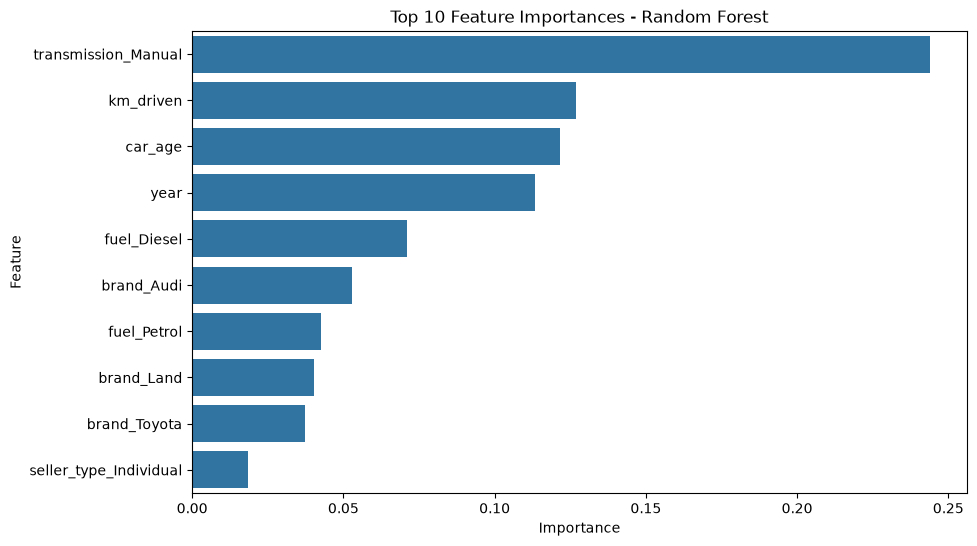

In [21]:
# Feature Importance of Random Forest

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

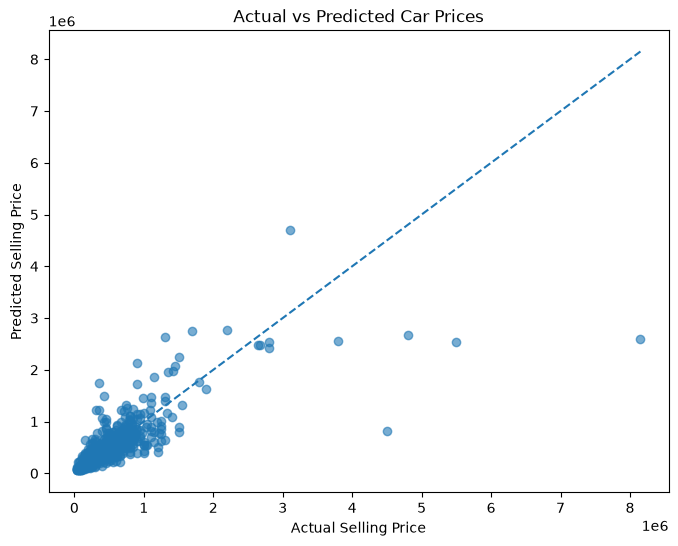

In [22]:
# Actual vs Predicted Selling Prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred_rf.min())
max_price = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')

plt.show()

## Conclusion

The Car Price Prediction project was successfully completed using
Linear Regression and Random Forest Regression.

- Data cleaning and feature engineering were performed.
- Car age and brand were created as additional features.
- Exploratory Data Analysis (EDA) was performed using different visualizations.
- Categorical variables were encoded for machine learning.
- Two regression models were trained and evaluated using MAE, RMSE, and R².
- Random Forest Regression achieved the highest R² score and was selected as the best-performing model.
- Feature importance was analyzed to identify the most influential features.
- Actual vs predicted prices were visualized to evaluate the model's predictions.

Overall, this project demonstrated the complete machine learning workflow
for predicting used car selling prices.